# Test dataset 크기 Slicing

In [2]:
# 모듈 

import nibabel as nib
import os 
import numpy as np

# 
from os.path import join as pjoin
import numpy as np
from dipy.viz import regtools
from dipy.data import fetch_stanford_hardi
from dipy.data.fetcher import fetch_syn_data
from dipy.io.image import load_nifti
from dipy.align.imaffine import (transform_centers_of_mass,
                                 AffineMap,
                                 MutualInformationMetric,
                                 AffineRegistration)
from dipy.align.transforms import (TranslationTransform3D,
                                   RigidTransform3D,
                                   AffineTransform3D)

In [3]:
import nibabel as nib
from skimage.transform import resize
import itertools

In [6]:
a = 1
filename = "./data/train/" + str(a) + ".nii.gz"
if os.path.isfile(filename):
    x = nib.load(filename).get_fdata()
#     x = x.swapaxes(0,2)
    print(x.shape)

(512, 512, 195)


In [3]:
filename = "./data/3step_exis/1.nii.gz"
x = nib.load(filename).get_fdata()
print(":", x.shape )


: (64, 512, 512)


In [7]:
a = 1

min = 0

for i in range (0, 90):
    filename = "./data/train/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.swapaxes(0,2)
        print(x.shape)
        
        x = x[:64]

        filename2 = "./change_trset_64/" +str(a) + ".nii.gz"
        x = nib.Nifti1Image(x, None) 
        nib.save(x, filename2)
        print(x.shape)
    a+=1

# filename = "./data/train/" + str(a) + ".nii.gz"
# x = nib.load(filename).get_fdata()
# print(x.shape)
# x = x.swapaxes(0,2)
# x = x[26:]
# x = nib.Nifti1Image(x, None) 
# nib.save(x,"3.nii.gz")

# print(x.shape)


(195, 512, 512)
(64, 512, 512)
(221, 512, 512)
(64, 512, 512)
(210, 512, 512)
(64, 512, 512)
(223, 512, 512)
(64, 512, 512)
(201, 512, 512)
(64, 512, 512)
(196, 512, 512)
(64, 512, 512)
(206, 512, 512)
(64, 512, 512)
(214, 512, 512)
(64, 512, 512)
(186, 512, 512)
(64, 512, 512)
(231, 512, 512)
(64, 512, 512)
(310, 512, 512)
(64, 512, 512)
(223, 512, 512)
(64, 512, 512)
(210, 512, 512)
(64, 512, 512)
(218, 512, 512)
(64, 512, 512)
(223, 512, 512)
(64, 512, 512)
(310, 512, 512)
(64, 512, 512)
(187, 512, 512)
(64, 512, 512)
(310, 512, 512)
(64, 512, 512)
(206, 512, 512)
(64, 512, 512)
(310, 512, 512)
(64, 512, 512)
(310, 512, 512)
(64, 512, 512)
(233, 512, 512)
(64, 512, 512)
(310, 512, 512)
(64, 512, 512)
(227, 512, 512)
(64, 512, 512)
(205, 512, 512)
(64, 512, 512)
(201, 512, 512)
(64, 512, 512)
(251, 512, 512)
(64, 512, 512)
(237, 512, 512)
(64, 512, 512)
(203, 512, 512)
(64, 512, 512)
(466, 512, 512)
(64, 512, 512)
(216, 512, 512)
(64, 512, 512)
(198, 512, 512)
(64, 512, 512)
(206, 51

# 검은색 걸러내기 

### 단순히 검은 색이 있는 곳을 지우는 형식으로 했는데 이렇게 하는 것이 아니라 
### 검은 색있는 부분을 Crop해서 사용해보자. 

In [11]:
a = 1

for i in range (0, 90):
    filename = "./data/train/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        
        print(a,":")
        va = 0
        for j in range(160,300):
            for k in range(160, 300):
                if x[j,k,0] == -1024:
                    va+=1
        if va > 10000:
            print(a,":", va)
#         x = x.swapaxes(0,2)
        print(x.shape)
    a+=1
    va = 0


1 :
(512, 512, 195)
3 :
(512, 512, 221)
4 :
(512, 512, 210)
5 :
(512, 512, 223)
6 :
(512, 512, 201)
8 :
(512, 512, 196)
9 :
(512, 512, 206)
11 :
(512, 512, 214)
12 :
(512, 512, 186)
13 :
(512, 512, 231)
14 :
14 : 19600
(512, 512, 310)
16 :
(512, 512, 223)
17 :
(512, 512, 210)
18 :
(512, 512, 218)
19 :
(512, 512, 223)
21 :
21 : 19600
(512, 512, 310)
22 :
(512, 512, 187)
23 :
23 : 19600
(512, 512, 310)
25 :
(512, 512, 206)
27 :
27 : 19600
(512, 512, 310)
28 :
28 : 19600
(512, 512, 310)
29 :
(512, 512, 233)
30 :
30 : 19600
(512, 512, 310)
32 :
(512, 512, 227)
33 :
(512, 512, 205)
34 :
(512, 512, 201)
35 :
(512, 512, 251)
36 :
(512, 512, 237)
38 :
(512, 512, 203)
39 :
(512, 512, 466)
40 :
(512, 512, 216)
41 :
(512, 512, 198)
43 :
(512, 512, 206)
44 :
(512, 512, 147)
45 :
(512, 512, 139)
46 :
(512, 512, 198)
47 :
(512, 512, 140)
48 :
(512, 512, 117)
50 :
(512, 512, 163)
51 :
(512, 512, 148)
52 :
(512, 512, 149)
53 :
(512, 512, 148)
54 :
(512, 512, 143)
56 :
(512, 512, 96)
57 :
(512, 512, 12

# Resize

In [3]:
def resize_data(data):
    initial_size_x = data.shape[0]
    initial_size_y = data.shape[1]
    initial_size_z = data.shape[2]

    new_size_x = 16
    new_size_y = 16
    new_size_z = 8

    delta_x = initial_size_x / new_size_x
    delta_y = initial_size_y / new_size_y
    delta_z = initial_size_z / new_size_z

    new_data = np.zeros((new_size_x, new_size_y, new_size_z))

    for x, y, z in itertools.product(range(new_size_x),
                                     range(new_size_y),
                                     range(new_size_z)):
        new_data[x][y][z] = data[int(x * delta_x)][int(y * delta_y)][int(z * delta_z)]

    return new_data

In [8]:
a = 40

for i in range (0, 1):
    filename = "./BTCV_Data/1resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        print(a, ":", x.shape )
        x = resize_data(x)
        # x = x.swapaxes(0,2) 
        print(a, ":", x.shape )
        savename = "./BTCV_Data/reszize_gt" + str(a) + ".nii.gz"
        
        x = nib.Nifti1Image(x, None) 
        nib.save(x, savename)
#         print(a, ":", x.shape )
    
    a+=1

# filename = "./data/train/" + str(a) + ".nii.gz"
# x = nib.load(filename).get_fdata()
# print(x.shape)
# x = x.swapaxes(0,2) 
# x = x[26:]
# x = nib.Nifti1Image(x, None) 
# nib.save(x,"3.nii.gz")

# print(x.shape)


40 : (128, 128, 64)
40 : (16, 16, 8)


# Exis 처리 

In [5]:
# voxel
a = 1

for i in range (0, 91):
    filename = "./chaos_train_voxel/3resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        print(a, ":", x.shape )
#         x = resize_data(x)
        x = x.swapaxes(0,2) 
        print(a, ":", x.shape )
        savename = "./chaos_train_voxel/4exis/" + str(a) + ".nii.gz"
        
        x = nib.Nifti1Image(x, None) 
        nib.save(x, savename)
#         print(a, ":", x.shape )
    
    a+=1

# filename = "./data/train/" + str(a) + ".nii.gz"
# x = nib.load(filename).get_fdata()
# print(x.shape)
# x = x.swapaxes(0,2) 
# x = x[26:]
# x = nib.Nifti1Image(x, None) 
# nib.save(x,"3.nii.gz")

# print(x.shape)


1 : (128, 128, 64)
1 : (64, 128, 128)
2 : (128, 128, 64)
2 : (64, 128, 128)
5 : (128, 128, 64)
5 : (64, 128, 128)
6 : (128, 128, 64)
6 : (64, 128, 128)
8 : (128, 128, 64)
8 : (64, 128, 128)
10 : (128, 128, 64)
10 : (64, 128, 128)
14 : (128, 128, 64)
14 : (64, 128, 128)
16 : (128, 128, 64)
16 : (64, 128, 128)
18 : (128, 128, 64)
18 : (64, 128, 128)
19 : (128, 128, 64)
19 : (64, 128, 128)
21 : (128, 128, 64)
21 : (64, 128, 128)
22 : (128, 128, 64)
22 : (64, 128, 128)
23 : (128, 128, 64)
23 : (64, 128, 128)
24 : (128, 128, 64)
24 : (64, 128, 128)
25 : (128, 128, 64)
25 : (64, 128, 128)
26 : (128, 128, 64)
26 : (64, 128, 128)
27 : (128, 128, 64)
27 : (64, 128, 128)
28 : (128, 128, 64)
28 : (64, 128, 128)
29 : (128, 128, 64)
29 : (64, 128, 128)
30 : (128, 128, 64)
30 : (64, 128, 128)


# Static data 처리 

In [13]:
filename = "./BTCV_Data/gt_resize/40.nii.gz"

x = nib.load(filename).get_fdata()
print(a, ":", x.shape )
# x = resize_data(x)
x = x.swapaxes(0,2) 
print(a, ":", x.shape )
savename = "./BTCV_Data/static_exis/40_gt.nii.gz"

x = nib.Nifti1Image(x, None) 
nib.save(x, savename)

39 : (128, 128, 64)
39 : (64, 128, 128)


In [14]:
a = 39
filename ="./IXI_/resize/39.nii.gz"

x = nib.load(filename).get_fdata()
print(a, ":", x.shape )
# x = resize_data(x)
x = x.swapaxes(0,2) 
print(a, ":", x.shape )
savename = "./IXI_/static_exis/40.nii.gz"

x = nib.Nifti1Image(x, None) 
nib.save(x, savename)


39 : (0,)


AxisError: axis2: axis 2 is out of bounds for array of dimension 1

In [8]:
filename = "./chaos_train_voxel/static_data/30.nii.gz"
a = 1
x = nib.load(filename).get_fdata()
print(a, ":", x.shape )
# x = resize_data(x)
x = x.swapaxes(0,2) 
print(a, ":", x.shape )
savename = "./chaos_train_voxel/static_data_exis/30.nii.gz"

x = nib.Nifti1Image(x, None) 
nib.save(x, savename)

1 : (128, 128, 64)
1 : (64, 128, 128)


In [4]:
data_dir = "./BTCV_Data/1resize"
data_list = sorted(os.listdir(data_dir))

In [3]:
st = []
a=1
for i in range (0, 40):
    filename = "./BTCV_Data/1resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.swapaxes(0,2)
        st.append(x)
        
        
    a+=1  
st = np.array(st)
print(st.shape)

savename = "./BTCV_Data/resize_exis_stack.nii.gz"

x = nib.Nifti1Image(st, None) 
nib.save(x, savename)

(30, 64, 128, 128)


In [3]:
st = []
a=1
for i in range (0, 40):
    filename = "./BTCV_Data/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.swapaxes(0,2)
        st.append(x)
        
        
    a+=1  
st = np.array(st)
print(st.shape)

savename = "./BTCV_Data/resize_exis_stack_gt.nii.gz"

x = nib.Nifti1Image(st, None) 
nib.save(x, savename)

(30, 64, 128, 128)


In [9]:
import nibabel as nib
import os 
import numpy as np

o1 = "./chaos_train_voxel/3resize/1.nii.gz"
o1 = nib.load(o1).get_fdata()

o2 = "./chaos_train_voxel/3resize/2.nii.gz"
o2 = nib.load(o2).get_fdata()

o5 = "./chaos_train_voxel/3resize/5.nii.gz"
o5 = nib.load(o5).get_fdata()

o6 = "./chaos_train_voxel/3resize/6.nii.gz"
o6 = nib.load(o6).get_fdata()

o8 = "./chaos_train_voxel/3resize/8.nii.gz"
o8 = nib.load(o8).get_fdata()

o10 = "./chaos_train_voxel/3resize/10.nii.gz"
o10 = nib.load(o10).get_fdata()

o14 = "./chaos_train_voxel/3resize/14.nii.gz"
o14 = nib.load(o14).get_fdata()

o16 = "./chaos_train_voxel/3resize/16.nii.gz"
o16 = nib.load(o16).get_fdata()

o18 = "./chaos_train_voxel/3resize/18.nii.gz"
o18 = nib.load(o18).get_fdata()

o19 = "./chaos_train_voxel/3resize/19.nii.gz"
o19 = nib.load(o19).get_fdata()

o21 = "./chaos_train_voxel/3resize/21.nii.gz"
o21 = nib.load(o21).get_fdata()

o22 = "./chaos_train_voxel/3resize/22.nii.gz"
o22 = nib.load(o22).get_fdata()

o23 = "./chaos_train_voxel/3resize/23.nii.gz"
o23 = nib.load(o23).get_fdata()

o24 = "./chaos_train_voxel/3resize/24.nii.gz"
o24 = nib.load(o24).get_fdata()

o25 = "./chaos_train_voxel/3resize/25.nii.gz"
o25 = nib.load(o25).get_fdata()

o26 = "./chaos_train_voxel/3resize/26.nii.gz"
o26 = nib.load(o26).get_fdata()

o27 = "./chaos_train_voxel/3resize/27.nii.gz"
o27 = nib.load(o27).get_fdata()

o28 = "./chaos_train_voxel/3resize/28.nii.gz"
o28 = nib.load(o28).get_fdata()

o29 = "./chaos_train_voxel/3resize/29.nii.gz"
o29 = nib.load(o29).get_fdata()

f = np.stack((o1,o2,o5,o6,o8,o10,o14,o16,o18,o19,o21,o22,o23,o24,o25,o26,o27,o28,o29), 0)

filename2 = "./chaos_train_voxel/affine_exis_mixed.nii.gz"
x = nib.Nifti1Image(f, None) 
nib.save(x, filename2)
print(x.shape)


(19, 64, 128, 128)


In [15]:
import nibabel as nib
import os 
import numpy as np

o1 = "./change_tr64/1.nii.gz"
o1 = nib.load(o1).get_fdata()

o3 = "./change_tr64/3.nii.gz"
o3 = nib.load(o3).get_fdata()

o4 = "./change_tr64/4.nii.gz"
o4 = nib.load(o4).get_fdata()

o5 = "./change_tr64/5.nii.gz"
o5 = nib.load(o5).get_fdata()

o6 = "./change_tr64/6.nii.gz"
o6 = nib.load(o6).get_fdata()

o8 = "./change_tr64/8.nii.gz"
o8 = nib.load(o8).get_fdata()

o9 = "./change_tr64/9.nii.gz"
o9 = nib.load(o9).get_fdata()

o11 = "./change_tr64/11.nii.gz"
o11 = nib.load(o11).get_fdata()

o12 = "./change_tr64/12.nii.gz"
o12 = nib.load(o12).get_fdata()

o13 = "./change_tr64/13.nii.gz"
o13 = nib.load(o13).get_fdata()

o16 = "./change_tr64/16.nii.gz"
o16 = nib.load(o16).get_fdata()

o17 = "./change_tr64/17.nii.gz"
o17 = nib.load(o17).get_fdata()

o18 = "./change_tr64/18.nii.gz"
o18 = nib.load(o18).get_fdata()

o19 = "./change_tr64/19.nii.gz"
o19 = nib.load(o19).get_fdata()

o22 = "./change_tr64/22.nii.gz"
o22 = nib.load(o22).get_fdata()

o25= "./change_tr64/25.nii.gz"
o25= nib.load(o25).get_fdata()

o29 = "./change_tr64/29.nii.gz"
o29 = nib.load(o29).get_fdata()

o32 = "./change_tr64/32.nii.gz"
o32 = nib.load(o32).get_fdata()

o33 = "./change_tr64/33.nii.gz"
o33 = nib.load(o33).get_fdata()

o34 = "./change_tr64/34.nii.gz"
o34 = nib.load(o34).get_fdata()

o35 = "./change_tr64/35.nii.gz"
o35 = nib.load(o35).get_fdata()

o36 = "./change_tr64/36.nii.gz"
o36 = nib.load(o36).get_fdata()

o38 = "./change_tr64/38.nii.gz"
o38 = nib.load(o38).get_fdata()

o39 = "./change_tr64/39.nii.gz"
o39 = nib.load(o39).get_fdata()

o40 = "./change_tr64/40.nii.gz"
o40 = nib.load(o40).get_fdata()

o41 = "./change_tr64/41.nii.gz"
o41 = nib.load(o41).get_fdata()

o43 = "./change_tr64/43.nii.gz"
o43 = nib.load(o43).get_fdata()

o44 = "./change_tr64/44.nii.gz"
o44 = nib.load(o44).get_fdata()

o45 = "./change_tr64/45.nii.gz"
o45 = nib.load(o45).get_fdata()

o46 = "./change_tr64/46.nii.gz"
o46 = nib.load(o46).get_fdata()

o47 = "./change_tr64/47.nii.gz"
o47 = nib.load(o47).get_fdata()

o48 = "./change_tr64/48.nii.gz"
o48 = nib.load(o48).get_fdata()

o50 = "./change_tr64/50.nii.gz"
o50 = nib.load(o50).get_fdata()

o51 = "./change_tr64/51.nii.gz"
o51 = nib.load(o51).get_fdata()

o52 = "./change_tr64/52.nii.gz"
o52 = nib.load(o52).get_fdata()

o53 = "./change_tr64/53.nii.gz"
o53 = nib.load(o53).get_fdata()

o54 = "./change_tr64/54.nii.gz"
o54 = nib.load(o54).get_fdata()

o56 = "./change_tr64/56.nii.gz"
o56 = nib.load(o56).get_fdata()

o57 = "./change_tr64/57.nii.gz"
o57 = nib.load(o57).get_fdata()

o59 = "./change_tr64/59.nii.gz"
o59 = nib.load(o59).get_fdata()

o60 = "./change_tr64/60.nii.gz"
o60 = nib.load(o60).get_fdata()

o62 = "./change_tr64/62.nii.gz"
o62 = nib.load(o62).get_fdata()

o63 = "./change_tr64/63.nii.gz"
o63 = nib.load(o63).get_fdata()

o64 = "./change_tr64/64.nii.gz"
o64 = nib.load(o64).get_fdata()

o65 = "./change_tr64/65.nii.gz"
o65 = nib.load(o65).get_fdata()

o66 = "./change_tr64/66.nii.gz"
o66 = nib.load(o66).get_fdata()

o68 = "./change_tr64/68.nii.gz"
o68 = nib.load(o68).get_fdata()

o69 = "./change_tr64/69.nii.gz"
o69 = nib.load(o69).get_fdata()

o71 = "./change_tr64/71.nii.gz"
o71 = nib.load(o71).get_fdata()

o72 = "./change_tr64/72.nii.gz"
o72 = nib.load(o72).get_fdata()

o73 = "./change_tr64/73.nii.gz"
o73 = nib.load(o73).get_fdata()

o74 = "./change_tr64/74.nii.gz"
o74 = nib.load(o74).get_fdata()

o75 = "./change_tr64/75.nii.gz"
o75 = nib.load(o75).get_fdata()

o77 = "./change_tr64/77.nii.gz"
o77 = nib.load(o77).get_fdata()

o78 = "./change_tr64/78.nii.gz"
o78 = nib.load(o78).get_fdata()

o80 = "./change_tr64/80.nii.gz"
o80 = nib.load(o80).get_fdata()

o81 = "./change_tr64/81.nii.gz"
o81 = nib.load(o81).get_fdata()

o82 = "./change_tr64/82.nii.gz"
o82 = nib.load(o82).get_fdata()

o83 = "./change_tr64/83.nii.gz"
o83 = nib.load(o83).get_fdata()

o84 = "./change_tr64/84.nii.gz"
o84 = nib.load(o84).get_fdata()

o86 = "./change_tr64/86.nii.gz"
o86 = nib.load(o86).get_fdata()

o87 = "./change_tr64/87.nii.gz"
o87 = nib.load(o87).get_fdata()

o89 = "./change_tr64/89.nii.gz"
o89 = nib.load(o89).get_fdata()

o90 = "./change_tr64/90.nii.gz"
o90 = nib.load(o90).get_fdata()

f = np.stack((o1, o3,o4,o5,o6,o8,o9,o11,o12,o13,o16,o17,o18,o19,o22,o25, o29, o32, o33, o34, o35 ,o36, o38, o39, o40, o41, o43, o44, o45, o46, o47, o48, o50, o51, o52, o53, o54, o56, o57, o59, o60, o62, o63, o64, o65, o66, o68, o69, o71, o72, o73, o74, o75,o77, o78, o80, o81, o82, o83, o84, o86, o87, o89, o90), 0)

filename2 = "./mix_data/mixed.nii.gz"
x = nib.Nifti1Image(f, None) 
nib.save(x, filename2)
print(x.shape)


(64, 64, 128, 128)


# Transformation 전체 처리

In [4]:
# files, folder = fetch_stanford_hardi()
static_data, static_affine, static_img = load_nifti(
                                            pjoin("./static_data/7.nii.gz"),
                                            return_img=True)

static = static_data
static_grid2world = static_affine



# files, folder2 = fetch_syn_data()
moving_data, moving_affine, moving_img = load_nifti(
                                            pjoin('./change_tr64/1.nii.gz'),
                                            return_img=True)
moving = moving_data
moving_grid2world = moving_affine

print(static_data.shape)
print(static.shape)
print(moving.shape)


(512, 512, 64)
(512, 512, 64)
(512, 512, 64)


In [5]:
# files, folder = fetch_stanford_hardi()
# static_data, static_affine, static_img = load_nifti(
#                                             pjoin(folder, 'HARDI150.nii.gz'),
#                                             return_img=True)
# static = np.squeeze(static_data)[..., 0]
# static_grid2world = static_affine

# files, folder2 = fetch_syn_data()
# moving_data, moving_affine, moving_img = load_nifti(
#                                             pjoin(folder2, 'b0.nii.gz'),
#                                             return_img=True)
# moving = moving_data
# moving_grid2world = moving_affine

# print(static_data.shape)
# print(static.shape)
# print(moving.shape)


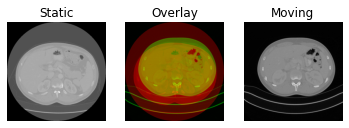

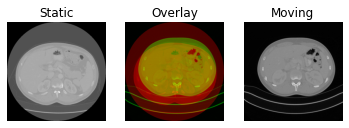

In [23]:
identity = np.eye(4)
affine_map = AffineMap(identity,
                       static.shape, static_grid2world,
                       moving.shape, moving_grid2world)
resampled = affine_map.transform(moving)
# regtools.overlay_slices(static, resampled, None, 0,
#                         "Static", "Moving", "resampled_0.png")
# regtools.overlay_slices(static, resampled, None, 1,
#                         "Static", "Moving", "resampled_1.png")
regtools.overlay_slices(static, resampled, None, 2,
                        "Static", "Moving", "resampled_2.png")

# Center Mass

In [8]:
c_of_mass = transform_centers_of_mass(static, static_grid2world,
                                      moving, moving_grid2world)


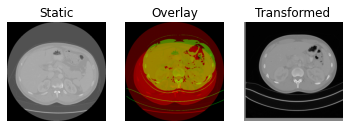

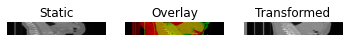

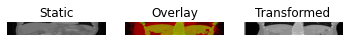

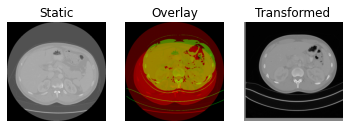

In [9]:
transformed = c_of_mass.transform(moving)
# regtools.overlay_slices(static, transformed, None, 0,
#                         "Static", "Transformed", "transformed_com_0.png")
# regtools.overlay_slices(static, transformed, None, 1,
#                         "Static", "Transformed", "transformed_com_1.png")
regtools.overlay_slices(static, transformed, None, 2,
                        "Static", "Transformed", "transformed_com_2.png")

# Translation

In [7]:
nbins = 32
sampling_prop = None
metric = MutualInformationMetric(nbins, sampling_prop)

level_iters = [10000, 1000, 100]

sigmas = [3.0, 1.0, 0.0]

factors = [4, 2, 1]

affreg = AffineRegistration(metric=metric,
                            level_iters=level_iters,
                            sigmas=sigmas,
                            factors=factors)

In [14]:
transform = TranslationTransform3D()
params0 = None
starting_affine = c_of_mass.affine
translation = affreg.optimize(static, moving, transform, params0,
                              static_grid2world, moving_grid2world,
                              starting_affine=starting_affine)

Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]


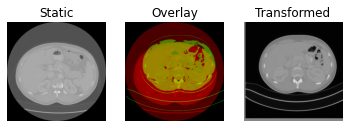

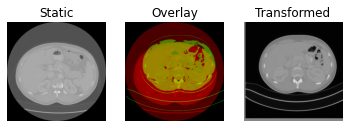

In [24]:
transformed = translation.transform(moving)
regtools.overlay_slices(static, transformed, None, 2,
                        "Static", "Transformed", "transformed_trans_2.png")

# Rigid Transformation

In [26]:
transform = RigidTransform3D()
params0 = None
starting_affine = translation.affine
rigid = affreg.optimize(static, moving, transform, params0,
                        static_grid2world, moving_grid2world,
                        starting_affine=starting_affine)

Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]


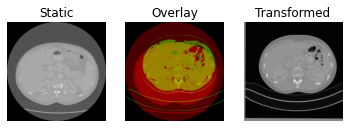

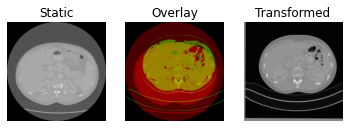

In [27]:
transformed = rigid.transform(moving)
regtools.overlay_slices(static, transformed, None, 2,
                        "Static", "Transformed", "transformed_rigid_2.png")

# Affine Translation 

In [34]:
transform = AffineTransform3D()
params0 = None
starting_affine = rigid.affine
affine = affreg.optimize(static, moving, transform, params0,
                         static_grid2world, moving_grid2world,
                         starting_affine=starting_affine)

Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]


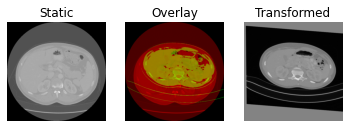

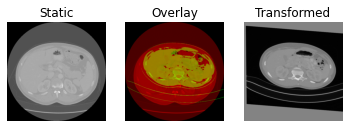

In [35]:
transformed = affine.transform(moving)
regtools.overlay_slices(static, transformed, None, 2,
                        "Static", "Transformed", "transformed_affine_2.png")

# pipe Line 으로 처리 

Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]


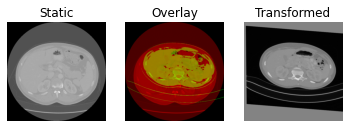

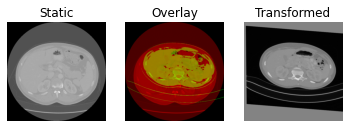

In [36]:
from dipy.align import affine_registration, register_dwi_to_template
pipeline = ["center_of_mass", "translation", "rigid", "affine"]

xformed_img, reg_affine = affine_registration(
    moving,
    static,
    moving_affine=moving_affine,
    static_affine=static_affine,
    nbins=32,
    metric='MI',
    pipeline=pipeline,
    level_iters=level_iters,
    sigmas=sigmas,
    factors=factors)

regtools.overlay_slices(static, xformed_img, None, 2,
                        "Static", "Transformed", "xformed_affine_2.png")

In [39]:
# save result
filename2 = "./data/2step_affine/" +str(a) + ".nii.gz"
# filename2 = "./data/2step_affine/1.nii.gz"
x = xformed_img
x = nib.Nifti1Image(x, None) 
nib.save(x, filename2)


# 반복 처리

In [8]:
nbins = 32
sampling_prop = None
metric = MutualInformationMetric(nbins, sampling_prop)

level_iters = [10000, 1000, 100]

sigmas = [3.0, 1.0, 0.0]

factors = [4, 2, 1]

affreg = AffineRegistration(metric=metric,
                            level_iters=level_iters,
                            sigmas=sigmas,
                            factors=factors)

In [10]:
# files, folder = fetch_stanford_hardi()
static_data, static_affine, static_img = load_nifti(
                                            pjoin("./chaos_train_voxel/static/30.nii.gz"),
                                            return_img=True)

static = static_data
static_grid2world = static_affine

a = 1

for i in range (0, 90):
    
    filename = "./chaos_train_voxel/3resize_real/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        print(a, "start!")
        x = nib.load(filename).get_fdata()
        
        moving_data, moving_affine, moving_img = load_nifti(
                                                    pjoin(filename),
                                                    return_img=True)
        moving = moving_data
        moving_grid2world = moving_affine
    
        identity = np.eye(4)

        from dipy.align import affine_registration, register_dwi_to_template
        pipeline = ["center_of_mass", "translation", "rigid", "affine"]

        xformed_img, reg_affine = affine_registration(
            moving,
            static,
            moving_affine=moving_affine,
            static_affine=static_affine,
            nbins=32,
            metric='MI',
            pipeline=pipeline,
            level_iters=level_iters,
            sigmas=sigmas,
            factors=factors)
    
        
        filename2 = "./chaos_train_voxel/4affine/" +str(a) + ".nii.gz"
        # filename2 = "./data/2step_affine/1.nii.gz"
        x = xformed_img
        x = nib.Nifti1Image(x, None) 
        nib.save(x, filename2)
        print(a, "finish")
    a+=1
    
    


1 start!
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
1 finish
2 start!
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
2 finish
5 start!
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0

In [14]:
# files, folder = fetch_stanford_hardi()
static_data, static_affine, static_img = load_nifti(
                                            pjoin("./chaos_train_voxel/static/30.nii.gz"),
                                            return_img=True)

static = static_data
static_grid2world = static_affine

a = 1

for i in range (0, 2):
    
    filename = "./chaos_train_voxel/3resize_real/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        print(a, "start!")
        x = nib.load(filename).get_fdata()
        
        moving_data, moving_affine, moving_img = load_nifti(
                                                    pjoin(filename),
                                                    return_img=True)
        moving = moving_data
        moving_grid2world = moving_affine
    
        identity = np.eye(4)

        from dipy.align import affine_registration, register_dwi_to_template
        pipeline = ["center_of_mass", "translation", "rigid", "affine"]

        xformed_img, reg_affine = affine_registration(
            moving,
            static,
            moving_affine=moving_affine,
            static_affine=static_affine,
            nbins=32,
            metric='MI',
            pipeline=pipeline,
            level_iters=level_iters,
            sigmas=sigmas,
            factors=factors)
    
        
        filename2 = "./chaos_train_voxel/4affine/" +str(a) + "yes.nii.gz"
        # filename2 = "./data/2step_affine/1.nii.gz"
        x = reg_affine
        x = nib.Nifti1Image(x, None) 
        nib.save(x, filename2)
        print(a, "finish")
    a+=1
    
    


1 start!
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
1 finish
2 start!
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]
Optimizing level 2 [max iter: 10000]
Optimizing level 1 [max iter: 1000]
Optimizing level 0 [max iter: 100]


KeyboardInterrupt: 

In [15]:
print(reg_affine.shape)

(4, 4)
